# Phase 2: Unsupervised Learning for Initial Detection (Anomaly-Based IDS)
# Task 2.1: Packet-Level Anomaly Detection
# K-Means

Build an unsupervised model that separates benign from non-benign packets.

## Setup, load metadata and sampled packet dataset

In [ ]:
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    silhouette_score
)

METADATA_FILE_NAME = "packet_sample_seed1.metadata.json"

## load packet dataset and metadata
PROJECT_ROOT = Path("..")
META_PATH = PROJECT_ROOT / "data" / "samples" / METADATA_FILE_NAME
with open(META_PATH, "r") as f:
    metadata = json.load(f)
metadata
DATA_PATH = PROJECT_ROOT / metadata["output_path"]
df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

## check class imbalance
BINARY_COL = "binary_label"
ATTACK_COL = "attack_type"
print(df[BINARY_COL].value_counts())
print()
print(df[ATTACK_COL].value_counts())

## Create numeric labels for evaluation only
y_true = df[BINARY_COL].map({
    "benign": 0,
    "attack": 1
}).to_numpy()

(205041, 138)
binary_label
benign    200000
attack      5041
Name: count, dtype: int64

attack_type
Benign             200000
DNS Spoofing         3178
DDoS-HTTP Flood       833
Brute Force           404
DoS-HTTP Flood        364
XSS                   262
Name: count, dtype: int64


## K-Means

### K-Means Data feature selections:

K-Means is distance-based, so numeric feature scaling is required.<br>
Text fields such as IP addresses, MAC addresses, host names, and user agents should not be directly used.<br>
These labels are removed before training to avoid leakage.<br>

In [274]:
# Basic packet-level features
base_features = [
    "time_since_previously_displayed_frame",
    "l4_tcp",
    "l4_udp",
    "ttl",
    "eth_size",
    "tcp_window_size",
    "payload_entropy",
    "jitter",
    "dns_len_qry",
    "dns_interval",
    "dns_len_ans",
    "http_content_len",
    "handshake_cipher_suites_length",
    "handshake_extensions_length",
    "handshake_sig_hash_alg_len",
    "l3_ip_dst_count"
]

# Use one rolling window to reduce redundancy
window_features = [
    "stream_5_count",
    "stream_5_mean",
    "stream_5_var",

    "src_ip_5_count",
    "src_ip_5_mean",
    "src_ip_5_var",

    "channel_5_count",
    "channel_5_mean",

    "stream_jitter_5_mean",
    "stream_jitter_5_var"
]

feature_cols = base_features + window_features

missing_features = [
    col for col in feature_cols
    if col not in df.columns
]

feature_cols = [
    col for col in feature_cols
    if col in df.columns
]

X_raw = df[feature_cols].copy()

# Replace the highly correlated payload_length feature
# with the payload proportion
packet_size = df["eth_size"].replace(0, np.nan)

X_raw["payload_ratio"] = (
    df["payload_length"] / packet_size
).fillna(0)

# Compare short-term activity with longer-term activity
def burst_ratio(short_col, long_col):
    short_count = pd.to_numeric(
        df[short_col],
        errors="coerce"
    ).fillna(0)

    long_count = pd.to_numeric(
        df[long_col],
        errors="coerce"
    ).fillna(0)

    # Activity during the most recent 5 units
    recent_rate = short_count / 5

    # Activity during the earlier 25 units
    previous_count = (long_count - short_count).clip(lower=0)
    previous_rate = previous_count / 25

    # Smoothing prevents division by zero
    return (recent_rate + 1) / (previous_rate + 1)


X_raw["stream_burst_ratio"] = burst_ratio(
    "stream_5_count",
    "stream_30_count"
)

X_raw["src_ip_burst_ratio"] = burst_ratio(
    "src_ip_5_count",
    "src_ip_30_count"
)

X_raw["channel_burst_ratio"] = burst_ratio(
    "channel_5_count",
    "channel_30_count"
)

burst_features = [
    "stream_burst_ratio",
    "src_ip_burst_ratio",
    "channel_burst_ratio"
]
print("\nBurst feature summary:")
print(X_raw[burst_features].describe())

print("Selected features:", X_raw.shape[1])
print("Missing requested features:", missing_features)

X_raw.head()


Burst feature summary:
       stream_burst_ratio  src_ip_burst_ratio  channel_burst_ratio
count       205041.000000       205041.000000        205041.000000
mean             3.347580            3.996210            10.869717
std             10.158807           22.913010            72.265694
min              0.020202            0.009728             0.076531
25%              1.129032            1.000000             1.005917
50%              1.400000            1.094675             1.116208
75%              2.193878            1.351351             1.486486
max            225.800000          867.500000           969.000000
Selected features: 30
Missing requested features: []


,time_since_previously_displayed_frame,l4_tcp,l4_udp,ttl,eth_size,tcp_window_size,payload_entropy,jitter,dns_len_qry,dns_interval,...,src_ip_5_mean,src_ip_5_var,channel_5_count,channel_5_mean,stream_jitter_5_mean,stream_jitter_5_var,payload_ratio,stream_burst_ratio,src_ip_burst_ratio,channel_burst_ratio
0,0.000185,1,0,64,60,0,0.000000,0.000185,0,0.0,...,117.428571,14842.041667,14.0,347.928571,75.288689,79105.166968,0.000000,3.800000,1.179039,3.800000
1,0.000290,1,0,49,66,65024,0.000000,0.000290,0,0.0,...,102.424242,11834.001894,65.0,105.861538,265.693714,635068.703264,0.000000,2.800000,1.085714,1.051051
2,0.003855,1,0,64,74,14600,0.000000,947.623914,0,0.0,...,104.813953,6684.535991,66.0,108.348485,947.623914,NaN,0.000000,1.200000,1.081081,1.072508
3,0.003104,0,1,64,60,0,3.201876,0.005255,0,0.0,...,88.576923,20528.013846,47.0,82.255319,0.305904,2.285203,0.266667,2.777778,1.371681,2.826087
4,0.000001,1,0,231,66,4415,0.000000,0.000001,0,0.0,...,66.000000,0.000000,354.0,1081.618644,0.015520,0.004361,0.000000,1.429706,1.451327,1.429140


### K-Means Basic preprocessing

Need to:<br>
&emsp;replace inf values<br>
&emsp;impute missing values with median<br>
&emsp;scale features<br>
&emsp;remove constant columns<br>

Missing and infinite values were replaced using median imputation because packet-level network features may contain undefined variance, jitter, or rate values. Constant columns were removed because they do not help clustering. Standard scaling was applied because K-Means uses Euclidean distance, and unscaled large-magnitude features would dominate the cluster assignment.

In [275]:
# Create 60% training, 20% validation and 20% test sets
all_idx = np.arange(len(df))

train_idx, temp_idx = train_test_split(
    all_idx,
    test_size=0.40,
    random_state=1,
    stratify=df[ATTACK_COL]
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=1,
    stratify=df.iloc[temp_idx][ATTACK_COL]
)

X_clean = X_raw.replace([np.inf, -np.inf], np.nan).copy()

# Missing variance or jitter means too few earlier packets
zero_fill_cols = [
    col for col in X_clean.columns
    if col.endswith("_var") or "jitter" in col
]

X_clean[zero_fill_cols] = X_clean[zero_fill_cols].fillna(0)

# Split before learning preprocessing information
X_train_df = X_clean.iloc[train_idx].copy()
X_val_df = X_clean.iloc[val_idx].copy()
X_test_df = X_clean.iloc[test_idx].copy()

# Identify unusable columns from training data only
drop_cols = [
    col for col in X_train_df.columns
    if X_train_df[col].isna().all()
    or X_train_df[col].nunique(dropna=True) <= 1
]

X_train_df = X_train_df.drop(columns=drop_cols)
X_val_df = X_val_df.drop(columns=drop_cols)
X_test_df = X_test_df.drop(columns=drop_cols)

# Identify skewed columns from training data only
log_cols = []

for col in X_train_df.columns:
    values = X_train_df[col].dropna()

    if (
        len(values) > 0
        and values.min() >= 0
        and abs(values.skew()) > 2
    ):
        log_cols.append(col)

for split in [X_train_df, X_val_df, X_test_df]:
    split[log_cols] = np.log1p(
        split[log_cols].clip(lower=0)
    )

preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_train = preprocess.fit_transform(X_train_df)
X_val = preprocess.transform(X_val_df)
X_test = preprocess.transform(X_test_df)

y_train = y_true[train_idx]
y_val = y_true[val_idx]
y_test = y_true[test_idx]

print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

print("\nAttack counts:")
print("Train:", y_train.sum())
print("Validation:", y_val.sum())
print("Test:", y_test.sum())

Training shape: (123024, 30)
Validation shape: (41008, 30)
Test shape: (41009, 30)

Attack counts:
Train: 3024
Validation: 1008
Test: 1009


### Tune K-Means hyperparameter k

Using inertia and silhouette score<br>
Because silhouette score is expensive on 205k rows, calculate it on a smaller random subset.<br>
Use Elbow method<br>

,k,inertia,silhouette,val_roc_auc,val_pr_auc,smallest_cluster,runtime_sec
0,4,2.387839e+06,0.193118,0.774698,0.060481,12597,0.402921
1,6,2.010593e+06,0.215416,0.788363,0.066755,2922,0.428197
2,8,1.662937e+06,0.251263,0.789335,0.071252,1717,0.435548
3,10,1.459938e+06,0.269681,0.795213,0.073511,344,0.500573
4,15,1.045226e+06,0.324567,0.823084,0.110843,344,0.613605
5,20,8.550463e+05,0.329555,0.831815,0.144023,344,0.761483
6,25,7.314904e+05,0.337690,0.824640,0.167684,344,0.944802
7,30,6.633980e+05,0.347816,0.827435,0.180782,344,1.071242
8,40,5.517530e+05,0.338177,0.833883,0.189286,344,1.250180
9,45,5.217680e+05,0.334925,0.840146,0.175808,344,1.356920


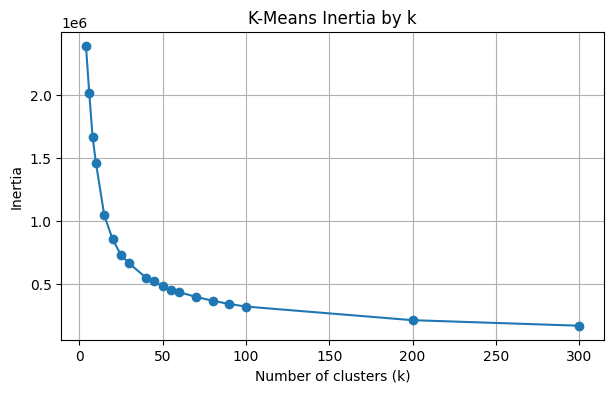

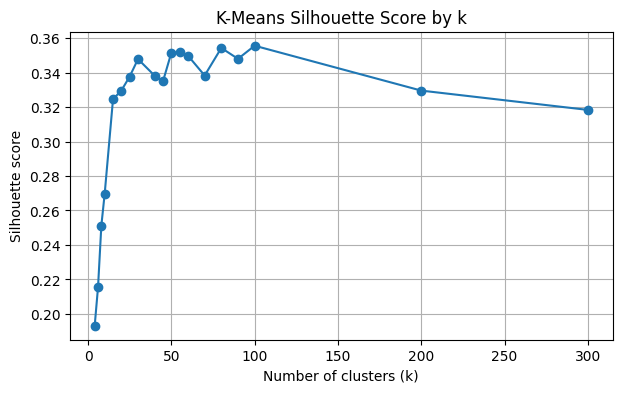

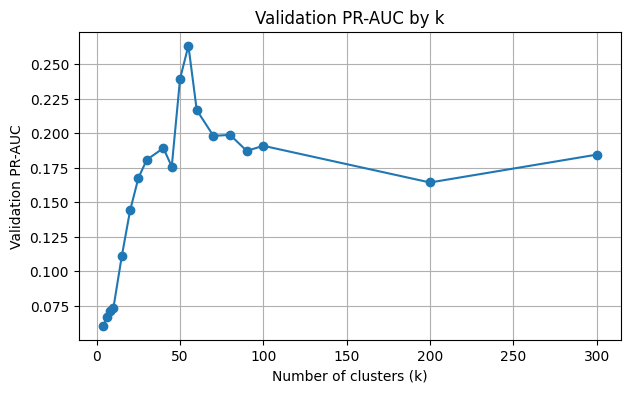

Selected k: 55
Validation PR-AUC: 0.2634895483615359
Validation ROC-AUC: 0.8533332589285715


In [276]:
k_values = [4, 6, 8, 10, 15, 20, 25, 30, 40, 45, 50, 55, 60, 70, 80, 90, 100, 200, 300]
# k_values = range(2, 15)
tuning_results = []

rng = np.random.default_rng(1)
sil_idx = rng.choice(X_train.shape[0], size=min(5000, X_train.shape[0]), replace=False)
X_sil = X_train[sil_idx]

for k in k_values:
    start = time.time()

    model = KMeans(n_clusters=k, random_state=1, n_init=5)
    train_labels = model.fit_predict(X_train)

    silhouette = silhouette_score(X_sil, train_labels[sil_idx])
    val_scores_k = model.transform(X_val).min(axis=1)
    cluster_sizes = np.bincount(train_labels)

    tuning_results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette,
        "val_roc_auc": roc_auc_score(y_val, val_scores_k),
        "val_pr_auc": average_precision_score(y_val, val_scores_k),
        "smallest_cluster": cluster_sizes.min(),
        "runtime_sec": time.time() - start
    })

kmeans_tuning_df = pd.DataFrame(tuning_results)
display(kmeans_tuning_df)


plt.figure(figsize=(7, 4))
plt.plot(kmeans_tuning_df["k"], kmeans_tuning_df["inertia"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("K-Means Inertia by k")
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(kmeans_tuning_df["k"], kmeans_tuning_df["silhouette"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("K-Means Silhouette Score by k")
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(kmeans_tuning_df["k"], kmeans_tuning_df["val_pr_auc"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Validation PR-AUC")
plt.title("Validation PR-AUC by k")
plt.grid(True)
plt.show()

best_row = kmeans_tuning_df.loc[kmeans_tuning_df["val_pr_auc"].idxmax()]
BEST_K = int(best_row["k"])
print("Selected k:", BEST_K)
print("Validation PR-AUC:", best_row["val_pr_auc"])
print("Validation ROC-AUC:", best_row["val_roc_auc"])

I trained each candidate K-Means model using only the training features and did not pass packet labels into the clustering algorithm. After fitting, I evaluated the resulting anomaly scores on the validation set using ROC-AUC and PR-AUC. Because the attack class is highly imbalanced, validation PR-AUC was used as the main criterion for selecting k. Among the tested values, k = 50 produced the highest validation PR-AUC, so it was selected for the final model. The test set was not used during hyperparameter selection.<br>

Inertia measures how close the data points are to their assigned cluster centers. A lower inertia usually means the clusters are more compact, but inertia will almost always decrease as k increases, so I used it mainly to look for an “elbow” point where the improvement starts to slow down.<br>

The silhouette score measures how well-separated the clusters are. A higher silhouette score means the clusters are more clearly separated. From the plot, the silhouette score is highest around k = 20 to k = 100. This suggests that using too few clusters may split the data into less meaningful groups.<br>

<!-- Based on both plots, I would choose **k = 4** as a reasonable starting value. It still has a high silhouette score, and the inertia has already improved compared with k = 2 and k = 3. I will use this value as the initial K-Means setting, then evaluate the anomaly detection performance using precision, recall, F1-score, FPR, FNR, AUC-ROC, and per-attack detection rate.<br> -->

I compared different values of k using inertia and silhouette score. These measures describe cluster compactness and separation, but they do not directly measure anomaly-detection performance. Smaller values such as k = 20 produced weaker detection results in later experiments, while k = 50 gave better ROC-AUC and F1-score with the current feature representation. Therefore, k = 50 is retained as the current baseline. Packet labels are not used when fitting K-Means and are used only afterward for evaluation.<br>

### Train K-Means model

In [277]:
# BEST_K = 50

start_train = time.time()

kmeans = KMeans(n_clusters=BEST_K, random_state=1, n_init=10)
kmeans.fit(X_train)

train_time = time.time() - start_train

train_cluster_labels = kmeans.labels_
val_cluster_labels = kmeans.predict(X_val)
test_cluster_labels = kmeans.predict(X_test)

cluster_sizes = pd.Series(train_cluster_labels).value_counts().sort_index()

print("Selected k:", BEST_K)
print("Training time:", train_time)
print("\nTraining cluster size summary:")
print(cluster_sizes.describe())

Selected k: 55
Training time: 3.628725051879883

Training cluster size summary:
count       55.000000
mean      2236.800000
std       2292.286465
min        228.000000
25%        911.000000
50%       1670.000000
75%       2802.000000
max      15784.000000
Name: count, dtype: float64


## Evaluation

### Phase 2 evaluation metrics

The project requires Phase 2 packet-level evaluation with precision, recall, F1-score, per-attack detection rate, FPR, FNR, AUC-ROC, and a confusion matrix. The function below keeps the output as one simple table so it can be compared with the K-Means results later.

In [278]:
# Raw distance to the nearest training centroid
val_scores = kmeans.transform(X_val).min(axis=1)
test_scores = kmeans.transform(X_test).min(axis=1)

df_val_result = df.iloc[val_idx].copy()
df_val_result["cluster"] = val_cluster_labels
df_val_result["anomaly_score"] = val_scores

df_test_result = df.iloc[test_idx].copy()
df_test_result["cluster"] = test_cluster_labels
df_test_result["anomaly_score"] = test_scores

### Threshold sensitivity analysis

The threshold controls the false-positive and false-negative trade-off. A lower alert rate usually reduces false positives but may miss more attacks. A higher alert rate usually catches more attacks but creates more false alarms. The table below tests a few alert rates around the project attack proportion. Labels are used here only for evaluation and analysis, not for model training.<br>

I selected the anomaly threshold using the validation set. Candidate thresholds were created from several alert-rate percentiles. To control false alarms, I limited the validation false-positive rate to 1.5% and then selected the candidate with the highest validation F1-score. This resulted in a 2% validation alert rate and a threshold of approximately 4.176. The same threshold was then applied to the test set without recalculation.

In [279]:
### Pick alert threshold
expected_attack_rate = metadata["total_attack_rows"] / metadata["total_rows"]
# threshold = np.quantile(anomaly_score, 1 - expected_attack_rate)
# df_result["y_pred"] = (df_result["anomaly_score"] >= threshold).astype(int)

### threshold sensitivity analysis, different attack rate
alert_rates = sorted({0.005, 0.01, 0.015, 0.02, expected_attack_rate, 0.03, 0.04, 0.05})

threshold_results = []

for alert_rate in alert_rates:
    current_threshold = np.quantile(val_scores, 1 - alert_rate)
    current_pred = (val_scores >= current_threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_val, current_pred, labels=[0, 1]).ravel()

    threshold_results.append({
        "alert_rate": alert_rate,
        "threshold": current_threshold,
        "alerts": current_pred.sum(),
        "precision": precision_score(y_val, current_pred, zero_division=0),
        "recall": recall_score(y_val, current_pred, zero_division=0),
        "f1": f1_score(y_val, current_pred, zero_division=0),
        "fpr": fp / (fp + tn),
        "fnr": fn / (fn + tp)
    })

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df)

,alert_rate,threshold,alerts,precision,recall,f1,fpr,fnr
0,0.005000,5.272714,206,0.538835,0.110119,0.182867,0.002375,0.889881
1,0.010000,4.618860,411,0.508516,0.207341,0.294574,0.005050,0.792659
2,0.015000,4.296116,616,0.431818,0.263889,0.327586,0.008750,0.736111
3,0.020000,4.065483,821,0.388551,0.316468,0.348824,0.012550,0.683532
4,0.024585,3.907578,1009,0.339941,0.340278,0.340109,0.016650,0.659722
5,0.030000,3.791926,1231,0.311129,0.379960,0.342117,0.021200,0.620040
6,0.040000,3.556670,1641,0.269957,0.439484,0.334466,0.029950,0.560516
7,0.050000,3.378093,2051,0.237445,0.483135,0.318405,0.039100,0.516865


In [ ]:
### Select validation threshold
TARGET_FPR = 0.015 # maximum acceptable FPR. maximum % of your negative cases to be incorrectly flagged as positive.
valid_thresholds = threshold_df[threshold_df["fpr"] <= TARGET_FPR]

if not valid_thresholds.empty:
    selected_row = valid_thresholds.loc[valid_thresholds["f1"].idxmax()]
else:
    selected_row = threshold_df.loc[threshold_df["fpr"].idxmin()]

FINAL_ALERT_RATE = float(selected_row["alert_rate"])
threshold = float(selected_row["threshold"])

print("Selected alert rate:", FINAL_ALERT_RATE)
print("Selected threshold:", threshold)
print("Validation F1:", selected_row["f1"])
print("Validation FPR:", selected_row["fpr"])


### Apply the threshold to validation and test data
val_pred = (val_scores >= threshold).astype(int)
test_pred = (test_scores >= threshold).astype(int)

df_test_result["model"] = "KMeans"
df_test_result["y_pred"] = test_pred

print("Validation alerts:", val_pred.sum())
print("Test alerts:", test_pred.sum())

Selected alert rate: 0.02
Selected threshold: 4.065482746830324
Validation F1: 0.348824494259158
Validation FPR: 0.01255
Validation alerts: 821
Test alerts: 791


In [287]:
# # Selected from the threshold sensitivity analysis
# FINAL_ALERT_RATE = 0.02

# # Threshold learned from validation scores
# threshold = np.quantile(val_scores, 1 - FINAL_ALERT_RATE)

# val_pred = (val_scores >= threshold).astype(int)
# test_pred = (test_scores >= threshold).astype(int)

# df_test_result["model"] = "KMeans"
# df_test_result["y_pred"] = test_pred

# print("Selected alert rate:", FINAL_ALERT_RATE)
# print("Validation threshold:", threshold)
# print("Test alerts:", test_pred.sum())

## Phase 2 metrics
def evaluate_phase2_detection(y_true, y_pred, scores, attack_types, model_name, runtime_sec):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    accuracy = accuracy_score(y_true, y_pred)

    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)

    auc_roc = roc_auc_score(y_true, scores)
    pr_auc = average_precision_score(y_true, scores)

    benign_count = (y_true == 0).sum()
    attack_count = (y_true == 1).sum()
    attack_rate = attack_count / len(y_true)

    result = {
        "model": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "fpr": fpr,
        "fnr": fnr,
        "auc_roc": auc_roc,
        "pr_auc": pr_auc,
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
        "benign_count": benign_count,
        "attack_count": attack_count,
        "attack_rate": attack_rate,
        "runtime_sec": runtime_sec
    }

    # Per-attack detection rate
    attack_names = ["DDoS-HTTP Flood", "DoS-HTTP Flood", "DNS Spoofing", "Brute Force", "XSS"]

    for attack in attack_names:
        attack_mask = attack_types == attack

        if attack_mask.sum() > 0:
            detection_rate = y_pred[attack_mask].mean()
        else:
            detection_rate = 0

        col_name = attack.lower().replace(" ", "_").replace("-", "_") + "_detect_rate"
        result[col_name] = detection_rate

    return result

metrics = evaluate_phase2_detection(
    y_true=y_test,
    y_pred=test_pred,
    scores=test_scores,
    attack_types=df_test_result[ATTACK_COL].to_numpy(),
    model_name="KMeans",
    runtime_sec=train_time
)

metrics_df = pd.DataFrame([metrics])
display(metrics_df)

,model,accuracy,precision,recall,f1,fpr,fnr,auc_roc,pr_auc,tp,...,fn,benign_count,attack_count,attack_rate,runtime_sec,ddos_http_flood_detect_rate,dos_http_flood_detect_rate,dns_spoofing_detect_rate,brute_force_detect_rate,xss_detect_rate
0,KMeans,0.970592,0.375474,0.294351,0.33,0.01235,0.705649,0.845502,0.239081,297,...,712,40000,1009,0.024604,3.628725,0.766467,0.547945,0.190252,0.074074,0.038462


### Results by traffic type

Classification results by traffic type:


,total,correct,incorrect,correct_rate
attack_type,,,,
Benign,40000,39506,494,98.76
DDoS-HTTP Flood,167,128,39,76.65
DoS-HTTP Flood,73,40,33,54.79
DNS Spoofing,636,121,515,19.03
Brute Force,81,6,75,7.41
XSS,52,2,50,3.85


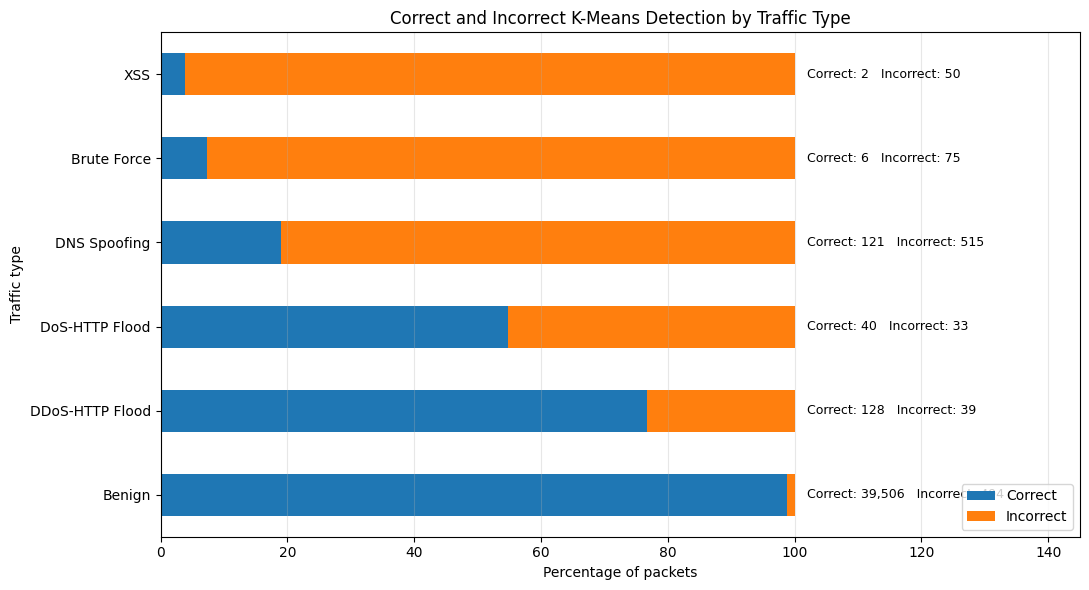

In [292]:
type_results = df_test_result[[ATTACK_COL]].copy()
type_results["y_true"] = y_test
type_results["y_pred"] = test_pred
type_results["correct"] = type_results["y_true"] == type_results["y_pred"]

result_by_type = type_results.groupby(ATTACK_COL).agg(total=("correct", "size"), correct=("correct", "sum"))
result_by_type["incorrect"] = result_by_type["total"] - result_by_type["correct"]
result_by_type["correct_rate"] = result_by_type["correct"] / result_by_type["total"] * 100
result_by_type["incorrect_rate"] = 100 - result_by_type["correct_rate"]

type_order = ["Benign", "DDoS-HTTP Flood", "DoS-HTTP Flood", "DNS Spoofing", "Brute Force", "XSS"]
result_by_type = result_by_type.reindex(type_order).dropna()

print("Classification results by traffic type:")
display(result_by_type[["total", "correct", "incorrect", "correct_rate"]].round(2))

# plot
plot_data = result_by_type[["correct_rate", "incorrect_rate"]]
ax = plot_data.plot(kind="barh", stacked=True, figsize=(11, 6))

for i, (_, row) in enumerate(result_by_type.iterrows()):
    count_text = f'Correct: {int(row["correct"]):,}   Incorrect: {int(row["incorrect"]):,}'
    ax.text(102, i, count_text, va="center", fontsize=9)
ax.set_xlim(0, 145)
ax.set_xlabel("Percentage of packets")
ax.set_ylabel("Traffic type")
ax.set_title("Correct and Incorrect K-Means Detection by Traffic Type")
ax.legend(["Correct", "Incorrect"], loc="lower right")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

#### Confusion matrix visualization

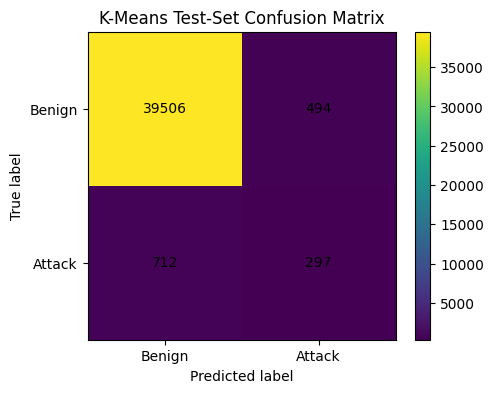

In [288]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    
    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.colorbar()
    
    classes = ["Benign", "Attack"]
    plt.xticks([0, 1], classes)
    plt.yticks([0, 1], classes)
    
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.show()

plot_confusion_matrix(
    y_test,
    test_pred,
    "K-Means Test-Set Confusion Matrix"
)

#### ROC curve

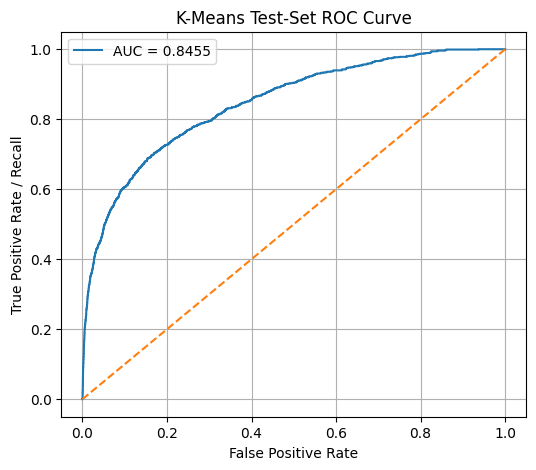

In [289]:
def plot_roc_curve(y_true, scores, title):
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    auc_value = roc_auc_score(y_true, scores)
    
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {auc_value:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate / Recall")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_roc_curve(
    y_test,
    test_scores,
    "K-Means Test-Set ROC Curve"
)

#### Precision-recall curve

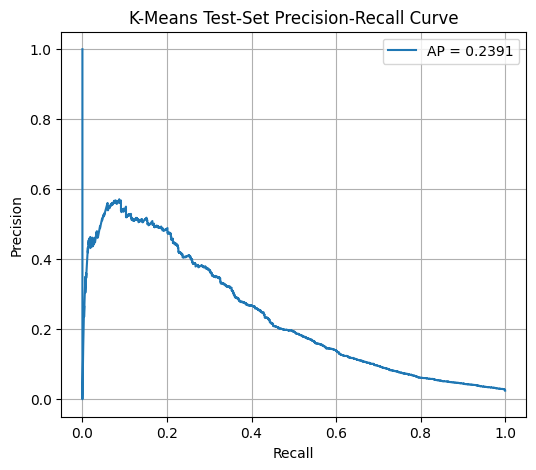

In [290]:
def plot_precision_recall_curve(y_true, scores, title):
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    ap = average_precision_score(y_true, scores)
    
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AP = {ap:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_precision_recall_curve(
    y_test,
    test_scores,
    "K-Means Test-Set Precision-Recall Curve"
)

### PCA cluster visualization

Use PCA to reduce the data to 2 dimensions to show clusters in 2D.

Explained variance: 0.4076277786571187


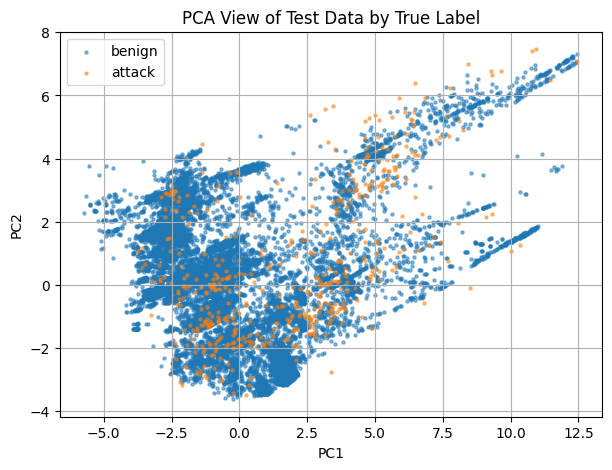

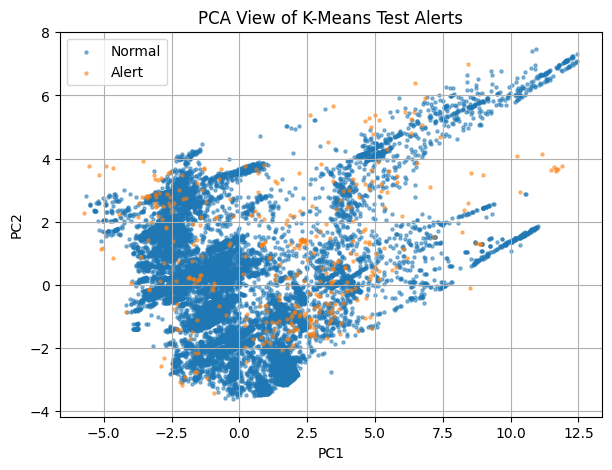

In [291]:
plot_size = min(20000, X_test.shape[0])
rng = np.random.default_rng(1)
plot_idx = rng.choice(X_test.shape[0], size=plot_size, replace=False)

pca = PCA(n_components=2, random_state=1)
X_2d = pca.fit_transform(X_test[plot_idx])

plot_df = pd.DataFrame({
    "PC1": X_2d[:, 0],
    "PC2": X_2d[:, 1],
    "cluster": df_test_result.iloc[plot_idx]["cluster"].to_numpy(),
    "binary_label": df_test_result.iloc[plot_idx][BINARY_COL].to_numpy(),
    "y_pred": df_test_result.iloc[plot_idx]["y_pred"].to_numpy(),
    "attack_type": df_test_result.iloc[plot_idx][ATTACK_COL].to_numpy()
})
print("Explained variance:", pca.explained_variance_ratio_.sum())


## Plot by true binary label
plt.figure(figsize=(7, 5))
for label in ["benign", "attack"]:
    temp = plot_df[plot_df["binary_label"] == label]
    plt.scatter(temp["PC1"], temp["PC2"], s=5, alpha=0.5, label=label)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA View of Test Data by True Label")
plt.legend()
plt.grid(True)
plt.show()


## Plot by predicted alert:
plt.figure(figsize=(7, 5))
for label in [0, 1]:
    temp = plot_df[plot_df["y_pred"] == label]
    name = "Normal" if label == 0 else "Alert"
    plt.scatter(temp["PC1"], temp["PC2"], s=5, alpha=0.5, label=name)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA View of K-Means Test Alerts")
plt.legend()
plt.grid(True)
plt.show()